# Importação e Organização dos Dados

In [ ]:
!pip install pydeseq2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

<font size=3>
Para conseguirmos desenvolver as análises com a distribuição binomial negativa, usada pelo PyDESeq2, precisamos de três componentes:

- **A Matriz de Contagens (_counts_):** Os nossos dados brutos (**não normalizados**, apenas números inteiros).
   
- **Os Metadados:** A tabela que indica quem é o Paciente 1, Paciente 2, e a qual grupo clínico pertencem.

- **O Desenho Experimental (_design formula_):** Onde dizemos à máquina exatamente o que queremos comparar.

In [4]:
df_xena = pd.read_csv('/content/drive/MyDrive/cancer-BRCA/datasets/TCGA-BRCA.star_counts.tsv.gz', sep='\t').set_index('Ensembl_ID')

x_raw = (2**df_xena) - 1
counts = x_raw.round().astype(int)

counts[counts < 0] = 0

counts = counts.T

del df_xena, x_raw

counts.head()

Ensembl_ID,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-D8-A146-01A,3414,210,2108,2100,560,562,3741,2054,2601,3261,...,0,0,39,0,0,0,290,0,6,30
TCGA-AQ-A0Y5-01A,879,9,2623,1727,421,218,3828,4182,2155,3156,...,0,0,14,0,0,0,767,0,6,37
TCGA-C8-A274-01A,8917,0,2908,4764,2010,247,1208,2072,1804,5088,...,0,0,41,0,0,0,983,0,14,19
TCGA-BH-A0BD-01A,2071,102,1784,2336,1735,448,3565,2318,1680,3288,...,0,0,20,0,1,0,770,0,7,13
TCGA-B6-A1KC-01B,2047,13,2155,1855,749,156,2433,2566,1823,5819,...,0,0,50,0,0,0,1579,0,4,13


In [5]:
metadata = pd.DataFrame(index=counts.index)

metadata['code'] = metadata.index.str[13:15]
metadata['Condicao'] = metadata['code'].apply(lambda x: 'Tumor' if int(x) < 10 else 'Normal')

metadata = metadata.drop(columns=['code'])

print(metadata.shape)
metadata.head(10)

(1226, 1)


,Condicao
TCGA-D8-A146-01A,Tumor
TCGA-AQ-A0Y5-01A,Tumor
TCGA-C8-A274-01A,Tumor
TCGA-BH-A0BD-01A,Tumor
TCGA-B6-A1KC-01B,Tumor
TCGA-AC-A62V-01A,Tumor
TCGA-AO-A0J5-01A,Tumor
TCGA-BH-A0B1-01A,Tumor
TCGA-A2-A0YM-01A,Tumor
TCGA-AO-A03N-01B,Tumor


In [6]:
n_genes = counts.shape[1]

# descobrindo o tamanho do menor grupo para usar como limite:
menor_grupo = metadata['Condicao'].value_counts().min()

print(f"O menor grupo tem {menor_grupo} amostras.")

genes_to_keep = (counts >= 10).sum(axis=0) >= menor_grupo
counts = counts.loc[:, genes_to_keep]

print(f"Nº de genes antes: {n_genes} | Nº de genes depois: {counts.shape[1]}")

O menor grupo tem 113 amostras.
Nº de genes antes: 60660 | Nº de genes depois: 26456


# PyDESeq2

## Desenho Experimental
<font size=3>

Para que o algoritmo saiba o que estamos testando, precisamos definir o nosso desenho experimental.

Nós apenas precisamos informar o nome da coluna (ou colunas) da nossa tabela de metadados que contém os grupos que queremos comparar. Ao passarmos o parâmetro design_factors="Condicao", estamos dizendo à máquina: "modele a expressão de cada gene assumindo que a principal variável que altera as contagens é a Condição clínica do paciente (Tumor vs. Normal)."

In [7]:
dds = DeseqDataSet(counts=counts, metadata=metadata,
                   design_factors="Condicao",
                   n_cpus=3) # processamento em paralelo

dds

/tmp/ipykernel_4803/2187651348.py:1: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts, metadata=metadata,


AnnData object with n_obs × n_vars = 1226 × 26456
    obs: 'Condicao'
    obsm: 'design_matrix'

In [8]:
%%time

print("A calcular fatores de tamanho, dispersões e a ajustar o modelo...")
dds.deseq2()

Fitting size factors...


A calcular fatores de tamanho, dispersões e a ajustar o modelo...
Using None as control genes, passed at DeseqDataSet initialization


... done in 2.08 seconds.

Fitting dispersions...
... done in 121.22 seconds.

Fitting dispersion trend curve...
... done in 0.76 seconds.

Fitting MAP dispersions...
... done in 121.72 seconds.

Fitting LFCs...
... done in 65.01 seconds.

Calculating cook's distance...
... done in 3.89 seconds.

Replacing 3230 outlier genes.

Fitting dispersions...
... done in 15.16 seconds.

Fitting MAP dispersions...
... done in 13.74 seconds.

Fitting LFCs...
... done in 11.17 seconds.



CPU times: user 26.2 s, sys: 5.48 s, total: 31.7 s
Wall time: 6min 37s


In [9]:
# extraindo os resultados
stat_results = DeseqStats(dds, contrast=["Condicao", "Tumor", "Normal"])
stat_results.summary()

Running Wald tests...
... done in 9.06 seconds.



Log2 fold change & Wald test p-value: Condicao Tumor vs Normal
                       baseMean  log2FoldChange     lfcSE       stat  \
Ensembl_ID                                                             
ENSG00000000003.15  3106.853568       -0.602655  0.092466  -6.517592   
ENSG00000000005.6    154.198482       -3.492146  0.252359 -13.838008   
ENSG00000000419.13  2304.523631        0.450519  0.055765   8.078883   
ENSG00000000457.14  1566.728651        0.387154  0.056213   6.887304   
ENSG00000000460.17   692.983844        1.323915  0.075471  17.542125   
...                         ...             ...       ...        ...   
ENSG00000288658.1     22.291543        0.484599  0.209849   2.309279   
ENSG00000288663.1     29.280973        0.269847  0.087801   3.073389   
ENSG00000288670.1    421.633726       -0.070600  0.067448  -1.046731   
ENSG00000288674.1      8.277070       -0.531241  0.093718  -5.668510   
ENSG00000288675.1     31.508085        1.427575  0.108613  13.143711   



In [10]:
results = stat_results.results_df

results.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Ensembl_ID,,,,,,
ENSG00000000003.15,3106.853568,-0.602655,0.092466,-6.517592,7.144502e-11,1.744163e-10
ENSG00000000005.6,154.198482,-3.492146,0.252359,-13.838008,1.503148e-43,1.507478e-42
ENSG00000000419.13,2304.523631,0.450519,0.055765,8.078883,6.536251e-16,2.091980e-15
ENSG00000000457.14,1566.728651,0.387154,0.056213,6.887304,5.685978e-12,1.481614e-11
ENSG00000000460.17,692.983844,1.323915,0.075471,17.542125,6.832357e-69,1.506307e-67


## Filtrando Biomarcadores

Entre as medidas que conseguimos nos resultados, existem duas mais importantes para  seguirmos com o processo da análise:

- **`log2FoldChange` (a magnitude e a direção):** O *Fold Change* é a razão entre a expressão do gene no Tumor e a expressão no tecido Normal. No entanto, usar uma razão simples cria um problema de assimetria. Se um gene aumenta 4 vezes no tumor, a razão é 4. Se ele diminui 4 vezes, a razão é 0.25, o que fica péssimo em um gráfico. Para resolver isso, aplicamos o logaritmo na base 2:
$$
    \text{L2FC} = \log_2\left(\frac{\text{Expressão no Tumor}}{\text{Expressão no Normal}}\right)
$$
    Com o Log2, a escala torna-se simétrica e intuitiva:
    * **L2FC de +1:** O gene dobrou de expressão no Tumor (2x mais).
    * **L2FC de +2:** O gene está 4 vezes mais expresso no Tumor.
    * **L2FC de -1:** A expressão do gene caiu pela metade no Tumor.
    * **L2FC de 0:** Nenhuma mudança (expressão igual em ambos).


- **`padj` (o p-valor Ajustado / FDR):** A bioinformática usa a coluna **`padj` (P-valor Ajustado)**, utilizando métodos matemáticos para controlar a **Taxa de Falsas Descobertas (FDR)**.

> Na prática, nós ignoramos a coluna `pvalue`. Para decidir se um gene é ou não um biomarcador, nós exigimos estritamente que o **`padj < 0.05`**.

In [11]:
results = results.dropna(subset=['padj', 'log2FoldChange'])

limite_padj = 0.05
limite_l2fc = 1.0 # Significa que a expressão do gene pelo menos dobrou ou caiu pela metade

genes_up = results[(results['padj'] < limite_padj) &
                   (results['log2FoldChange'] > limite_l2fc)]

genes_down = results[(results['padj'] < limite_padj) &
                     (results['log2FoldChange'] < -limite_l2fc)]

print(f"Descobrimos {genes_up.shape[0]} genes significativamente Super-expressos no Tumor.")
print(f"Descobrimos {genes_down.shape[0]} genes significativamente Sub-expressos no Tumor.")

Descobrimos 4374 genes significativamente Super-expressos no Tumor.
Descobrimos 2607 genes significativamente Sub-expressos no Tumor.


In [12]:
genes_up.to_csv("genes_up.csv")
genes_down.to_csv("genes_down.csv")

# Visualização de Resultados

## Volcano Plot

In [13]:
results['nlog10'] = -np.log10(results['padj'] + 1e-300)

def categorizar_gene(row):
    if row['padj'] < limite_padj and row['log2FoldChange'] > limite_l2fc:
        return 'Super-expresso (Tumor)'

    elif row['padj'] < limite_padj and row['log2FoldChange'] < -limite_l2fc:
        return 'Sub-expresso (Tumor)'

    else:
        return 'Não significativo (baixa magnitude)'

results['Categoria'] = results.apply(categorizar_gene, axis=1)

results.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,nlog10,Categoria
Ensembl_ID,,,,,,,,
ENSG00000000003.15,3106.853568,-0.602655,0.092466,-6.517592,7.144502e-11,1.744163e-10,9.758413,Não significativo (baixa magnitude)
ENSG00000000005.6,154.198482,-3.492146,0.252359,-13.838008,1.503148e-43,1.507478e-42,41.821749,Sub-expresso (Tumor)
ENSG00000000419.13,2304.523631,0.450519,0.055765,8.078883,6.536251e-16,2.091980e-15,14.679443,Não significativo (baixa magnitude)
ENSG00000000457.14,1566.728651,0.387154,0.056213,6.887304,5.685978e-12,1.481614e-11,10.829265,Não significativo (baixa magnitude)
ENSG00000000460.17,692.983844,1.323915,0.075471,17.542125,6.832357e-69,1.506307e-67,66.822087,Super-expresso (Tumor)


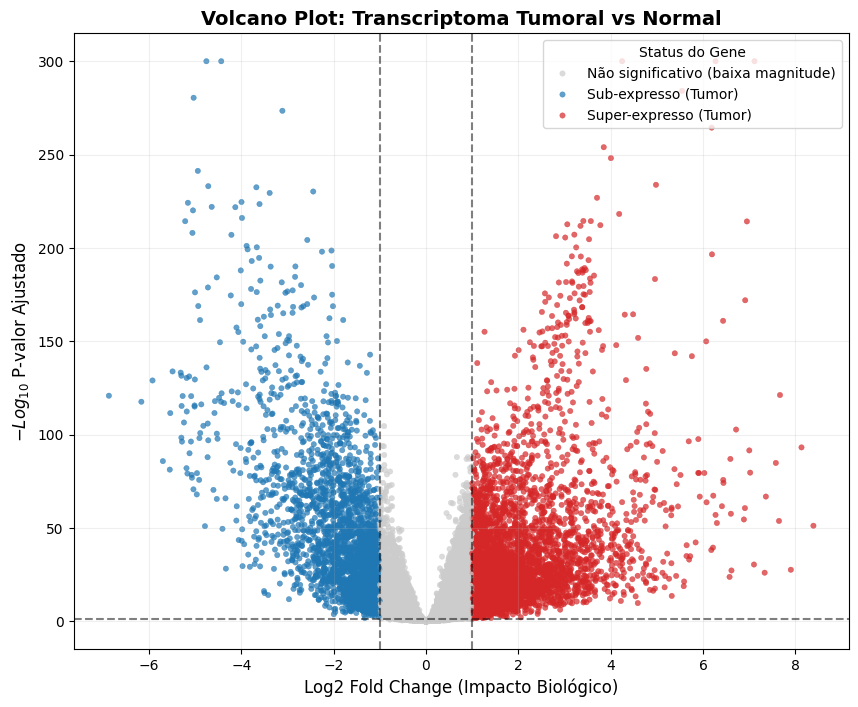

In [14]:
plt.figure(figsize=(10, 8))
plt.title('Volcano Plot: Transcriptoma Tumoral vs Normal', fontsize=14, fontweight='bold')

sns.scatterplot(data=results, x='log2FoldChange', y='nlog10', hue='Categoria',
                palette={'Super-expresso (Tumor)': 'tab:red',
                         'Sub-expresso (Tumor)': 'tab:blue',
                         'Não significativo (baixa magnitude)': '#CCCCCC'},
                alpha=0.7, edgecolor=None, s=15)

plt.axvline(limite_l2fc, color='black', linestyle='--', alpha=0.5)
plt.axvline(-limite_l2fc, color='black', linestyle='--', alpha=0.5)
plt.axhline(-np.log10(limite_padj), color='black', linestyle='--', alpha=0.5)

plt.xlabel('Log2 Fold Change (Impacto Biológico)', fontsize=12)
plt.ylabel('$-Log_{10}$ P-valor Ajustado', fontsize=12)
plt.legend(title="Status do Gene", loc='upper right')
plt.grid(alpha=0.2)
plt.show()

## MA-Plot

<font size=3>
Enquanto o Volcano foca na decisão, o MA-Plot é o nosso principal gráfico de diagnóstico de qualidade.  Ele mostra como a magnitude (`L2FC`) se comporta em relação à abundância real do gene (`baseMean`).

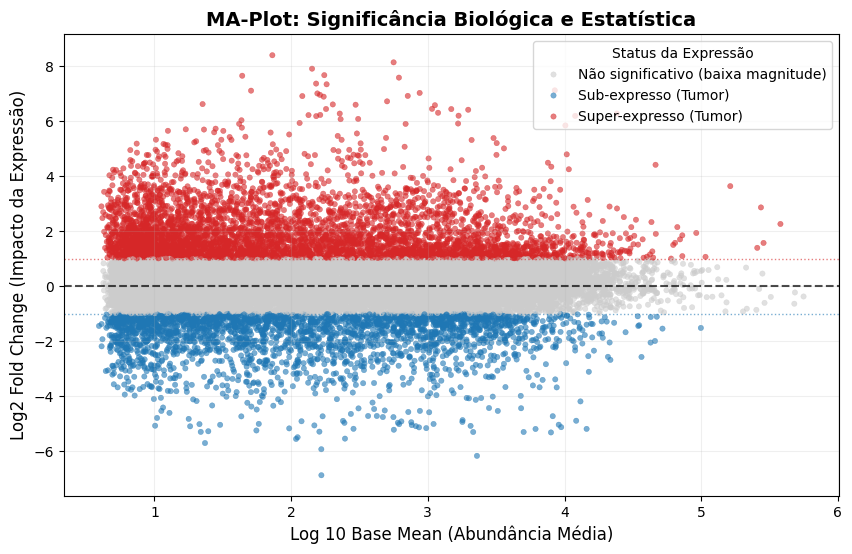

In [15]:
cores = {'Super-expresso (Tumor)':'tab:red',
         'Sub-expresso (Tumor)':'tab:blue',
         'Não significativo (baixa magnitude)':'#CCCCCC'}

plt.figure(figsize=(10, 6))

sns.scatterplot(x=np.log10(results['baseMean'] + 1), y=results['log2FoldChange'],
                hue=results['Categoria'], palette=cores, alpha=0.6, edgecolor=None, s=15)

plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(limite_l2fc, color='tab:red', linestyle=':', linewidth=1, alpha=0.6)
plt.axhline(-limite_l2fc, color='tab:blue', linestyle=':', linewidth=1, alpha=0.6)

plt.title('MA-Plot: Significância Biológica e Estatística', fontsize=14, fontweight='bold')
plt.xlabel('Log 10 Base Mean (Abundância Média)', fontsize=12)
plt.ylabel('Log2 Fold Change (Impacto da Expressão)', fontsize=12)
plt.legend(title='Status da Expressão', loc='upper right')
plt.grid(alpha=0.2)
plt.show()

<font size=3>

No plote acima, vemos:
 * **A cauda larga à esquerda:** Repare como os genes com baixo `baseMean` (à esquerda do eixo X) espalham-se amplamente para cima e para baixo (é o ruído que discutimos). Felizmente, a maioria está em cinza, provando que o PyDESeq2 fez um bom trabalho ao penalizar esses genes através do P-valor.
    
 * **O afunilamento à direita:** Genes muito expressos (à direita) tendem a ter um $L2FC$ mais contido e confiável.
    
 * **Os pontos vermelhos e azuis:** São os genes em que realmente podemos confiar para a pesquisa.
    

## Heatmap

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 1200x1600 with 0 Axes>

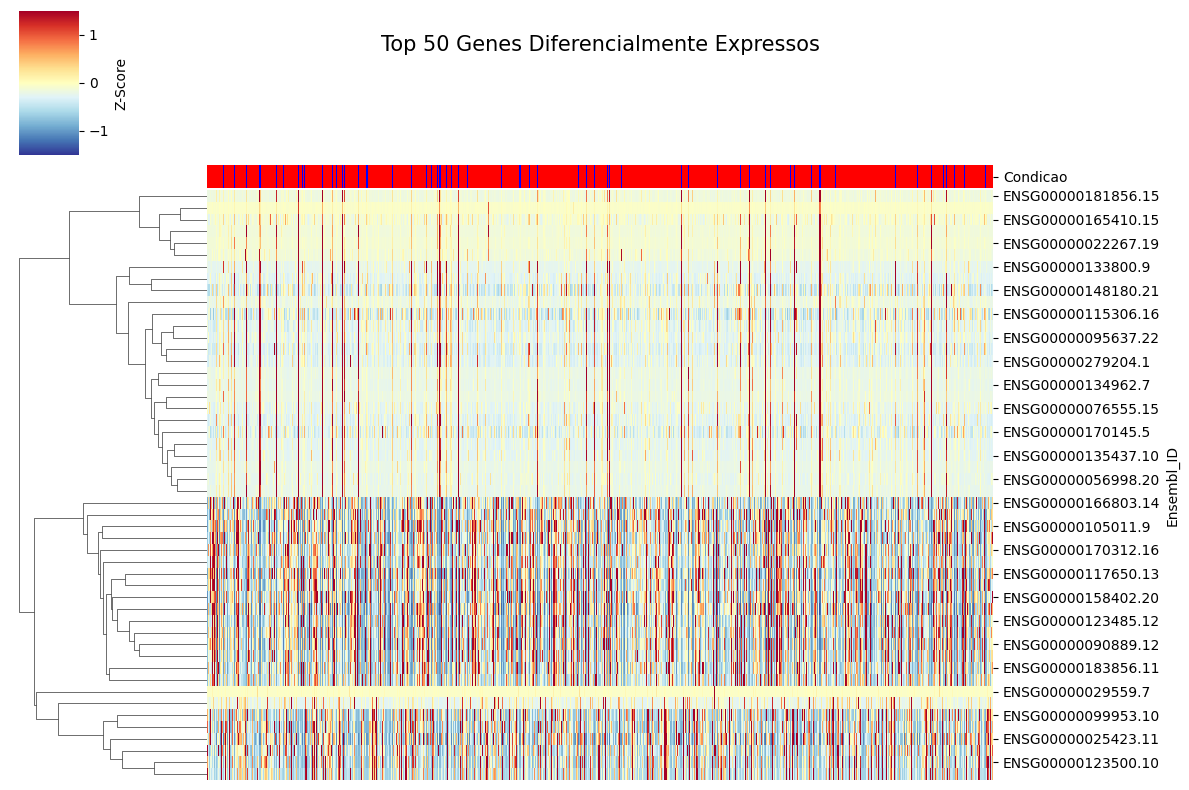

In [16]:
normed_df = pd.DataFrame(dds.layers['normed_counts'], index=dds.obs_names, columns=dds.var_names).T

top_50_genes = results.sort_values('padj').head(50).index
matriz = normed_df.loc[top_50_genes]

matriz = matriz.apply(lambda x: (x - x.mean())/x.std(), axis=1)

colors = dds.obs['Condicao'].map({'Tumor': 'red', 'Normal': 'blue'})

plt.figure(figsize=(12, 16))

g = sns.clustermap(matriz, cmap='RdYlBu_r', center=0, col_colors=colors, figsize=(12, 8), linewidth=0,
                   col_cluster=False, xticklabels=False, vmin=-1.5, vmax=1.5, cbar_kws={'label': 'Z-Score'})

g.ax_heatmap.set_title('Top 50 Genes Diferencialmente Expressos', pad=100, fontsize=15)

plt.show()

<font size=3>
No gráfico acima, cada linha horizontal representa um gene individual e cada coluna vertical fininha é um paciente (amostra). A interpretação é guiada pelas cores: tons em vermelho forte indicam que o gene está super-expresso (trabalhando muito acima da média) naquela amostra, enquanto tons em azul escuro revelam sub-expressão (gene "silenciado" ou abaixo da média).

Ao cruzar essas cores com a barra de classificação no topo (que separa os pacientes em grupos, como Tumor e Normal), o que buscamos enxergar são grandes "blocos sólidos" de cor. Se você visualiza uma faixa que é predominantemente vermelha na seção do Tumor e azul na seção Normal, você está enxergando a assinatura genética da doença a olho nu: um conjunto de genes que o tumor consistentemente "liga" para sobreviver e se multiplicar, enquanto no tecido saudável eles permanecem inativos.